In [2]:
import pandas as pd
import numpy as np

# Load ratings
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')

# Load movies
movies = pd.read_csv('../data/ml-latest-small/movies.csv')

# Load tags
tags = pd.read_csv('../data/ml-latest-small/tags.csv')

print("✅ Data loaded successfully!")
print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape:  {movies.shape}")
print(f"Tags shape:    {tags.shape}")

✅ Data loaded successfully!
Ratings shape: (100836, 4)
Movies shape:  (9742, 3)
Tags shape:    (3683, 4)


In [3]:
print("=== RATINGS (first 5 rows) ===")
print(ratings.head())

print("\n=== MOVIES (first 5 rows) ===")
print(movies.head())

print("\n=== TAGS (first 5 rows) ===")
print(tags.head())

=== RATINGS (first 5 rows) ===
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

=== MOVIES (first 5 rows) ===
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

=== TAGS (first 5 rows) ===
   userId  movieId              tag   timestamp
0       2    60756            funny  1

In [4]:
print("=== Missing values check ===")

print("\nRatings:")
print(ratings.isnull().sum())

print("\nMovies:")
print(movies.isnull().sum())

print("\nTags:")
print(tags.isnull().sum())

=== Missing values check ===

Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Movies:
movieId    0
title      0
genres     0
dtype: int64

Tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


In [5]:
print("=== Rating statistics ===")
print(ratings['rating'].describe())

print(f"\nTotal unique users:  {ratings['userId'].nunique()}")
print(f"Total unique movies: {ratings['movieId'].nunique()}")
print(f"Total ratings:       {len(ratings)}")
print(f"Rating scale:        {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Average rating:      {ratings['rating'].mean():.2f}")

=== Rating statistics ===
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Total unique users:  610
Total unique movies: 9724
Total ratings:       100836
Rating scale:        0.5 to 5.0
Average rating:      3.50


C:\Users\Prathish Thiyageson\AppData\Local\Temp\ipykernel_16444\3267957294.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='Blues_d')


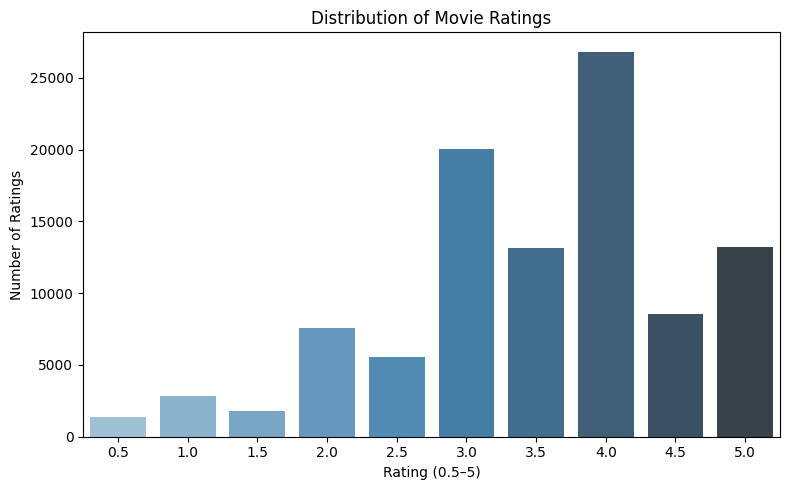

✅ Chart saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='Blues_d')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating (0.5–5)')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.savefig('../data/rating_distribution.png')
plt.show()
print("✅ Chart saved!")

In [7]:
# Merge ratings with movie titles
movie_stats = ratings.merge(movies, on='movieId')

# Count ratings per movie
most_rated = (
    movie_stats.groupby('title')['rating']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'num_ratings', 'mean': 'avg_rating'})
    .sort_values('num_ratings', ascending=False)
    .head(10)
    .reset_index()
)

print("=== Top 10 Most Rated Movies ===")
print(most_rated.to_string(index=False))

=== Top 10 Most Rated Movies ===
                                    title  num_ratings  avg_rating
                      Forrest Gump (1994)          329    4.164134
         Shawshank Redemption, The (1994)          317    4.429022
                      Pulp Fiction (1994)          307    4.197068
         Silence of the Lambs, The (1991)          279    4.161290
                       Matrix, The (1999)          278    4.192446
Star Wars: Episode IV - A New Hope (1977)          251    4.231076
                     Jurassic Park (1993)          238    3.750000
                        Braveheart (1995)          237    4.031646
        Terminator 2: Judgment Day (1991)          224    3.970982
                  Schindler's List (1993)          220    4.225000


C:\Users\Prathish Thiyageson\AppData\Local\Temp\ipykernel_16444\1237309876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


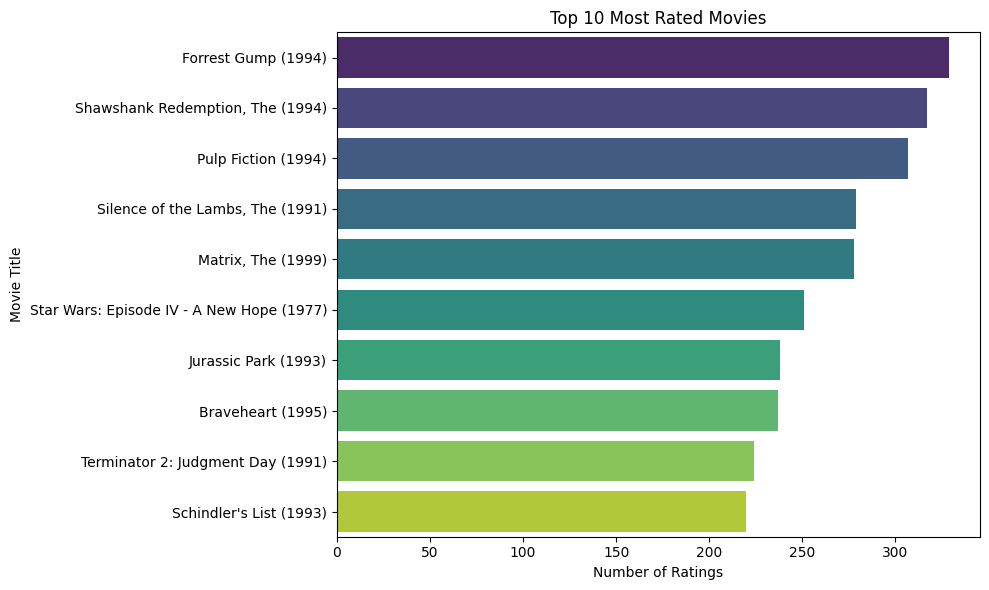

✅ Chart saved!


In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=most_rated,
    x='num_ratings',
    y='title',
    palette='viridis'
)
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.savefig('../data/top_rated_movies.png')
plt.show()
print("✅ Chart saved!")

=== Ratings per user ===
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64


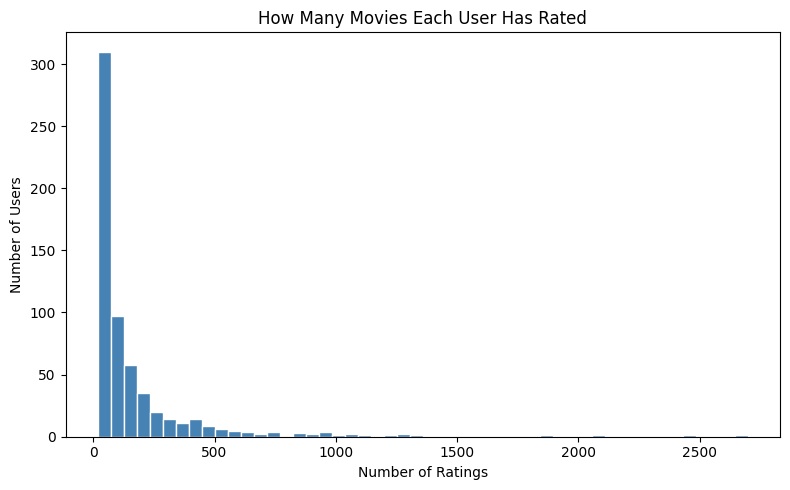

✅ Chart saved!


In [9]:
ratings_per_user = ratings.groupby('userId')['rating'].count()

print("=== Ratings per user ===")
print(ratings_per_user.describe())

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
plt.title('How Many Movies Each User Has Rated')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('../data/ratings_per_user.png')
plt.show()
print("✅ Chart saved!")

In [10]:
# Merge ratings + movies into one clean dataframe
clean_data = ratings.merge(movies, on='movieId')

# Drop timestamp column (not needed)
clean_data = clean_data.drop(columns=['timestamp'])

print("=== Clean merged dataset ===")
print(clean_data.head(10))
print(f"\nShape: {clean_data.shape}")

# Save it
clean_data.to_csv('../data/clean_data.csv', index=False)
print("\n✅ Clean data saved to data/clean_data.csv")

=== Clean merged dataset ===
   userId  movieId  rating                        title  \
0       1        1     4.0             Toy Story (1995)   
1       1        3     4.0      Grumpier Old Men (1995)   
2       1        6     4.0                  Heat (1995)   
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0   Usual Suspects, The (1995)   
5       1       70     3.0   From Dusk Till Dawn (1996)   
6       1      101     5.0         Bottle Rocket (1996)   
7       1      110     4.0            Braveheart (1995)   
8       1      151     5.0               Rob Roy (1995)   
9       1      157     5.0        Canadian Bacon (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  
5                Action|Com

In [11]:
print("=== Final Summary ===")
print(f"Total ratings:        {len(clean_data)}")
print(f"Total unique users:   {clean_data['userId'].nunique()}")
print(f"Total unique movies:  {clean_data['title'].nunique()}")
print(f"Rating range:         {clean_data['rating'].min()} – {clean_data['rating'].max()}")
print(f"Average rating:       {clean_data['rating'].mean():.2f}")
print("\n✅ Phase 2 complete! Ready to build models.")

=== Final Summary ===
Total ratings:        100836
Total unique users:   610
Total unique movies:  9719
Rating range:         0.5 – 5.0
Average rating:       3.50

✅ Phase 2 complete! Ready to build models.
